<a href="https://colab.research.google.com/github/yerardinespinosab15-afk/challengtelexon2/blob/main/telecomX2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Extracción:**

In [2]:
import pandas as pd
import requests

# 1. Definimos la ruta o URL del archivo
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/5adf5f2f87a72bd8b2e854db16e2f2f7c499081a/TelecomX_Data.json'

# 2. Obtenemos los datos de la ruta
response = requests.get(url)
json_data = response.json()

# 3. Transformamos a DataFrame (Aplanando los datos anidados)
# Usamos record_path si el JSON tiene una raíz específica, pero para este reto
# json_normalize directo suele funcionar para columnas como 'Charges.Total'
df = pd.json_normalize(json_data)

# 4. Verificación inicial
print("Columnas detectadas:", df.columns)
df.head()

Columnas detectadas: Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


**Transformación y Preparación de Datos**

Proporción de Churn (Evasión):
Churn
0.0    0.734215
1.0    0.265785
Name: proportion, dtype: float64


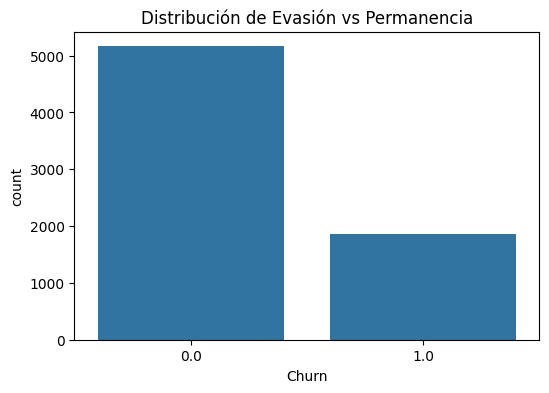

In [4]:
# 1. Eliminar columna irrelevante para el modelo
df_prep = df.drop(columns=['customerID'])

# 2. Convertir 'Charges.Total' a numérico (a veces viene como texto con espacios)
df_prep['account.Charges.Total'] = pd.to_numeric(df_prep['account.Charges.Total'], errors='coerce')
df_prep.dropna(inplace=True) # Eliminamos nulos resultantes

# 3. Transformar variables categóricas (Encoding)
# Convertimos Churn a 1 (Sí) y 0 (No)
df_prep['Churn'] = df_prep['Churn'].map({'Yes': 1, 'No': 0})

# Aplicamos get_dummies para el resto de variables (Género, Contrato, etc.)
df_final_model = pd.get_dummies(df_prep)

# 4. Verificar proporción de cancelación (Análisis de clases)
print("Proporción de Churn (Evasión):")
print(df_final_model['Churn'].value_counts(normalize=True))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df_prep)
plt.title('Distribución de Evasión vs Permanencia')
plt.show()

**Modelado y Selección de Variables**


--- Informe de Métricas ---
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1554
         1.0       0.61      0.49      0.55       556

    accuracy                           0.78      2110
   macro avg       0.72      0.69      0.70      2110
weighted avg       0.77      0.78      0.78      2110



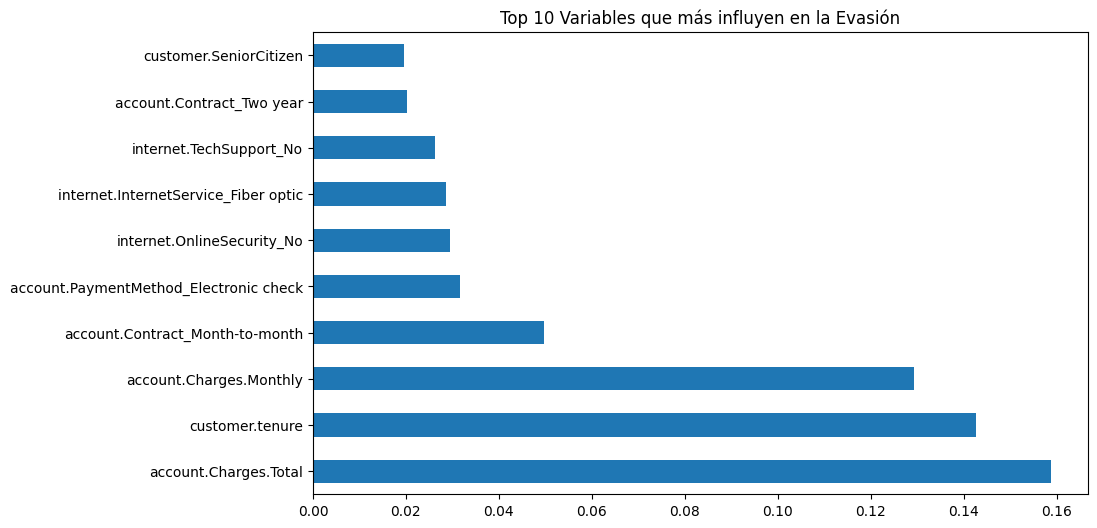

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Asegurarse de que la columna 'Churn' no tenga NaNs
df_final_model.dropna(subset=['Churn'], inplace=True)

# Separar variables predictoras (X) del objetivo (y)
X = df_final_model.drop(columns=['Churn'])
y = df_final_model['Churn']

# Dividir en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear y entrenar el modelo (Bosque Aleatorio)
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Evaluación del modelo
predicciones = modelo.predict(X_test)
print("\n--- Informe de Métricas ---")
print(classification_report(y_test, predicciones))

# Análisis de Importancia de Variables
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importancias.head(10).plot(kind='barh')
plt.title('Top 10 Variables que más influyen en la Evasión')
plt.show()

### 6. Análisis de Correlación de Variables
Para entender mejor las relaciones entre las variables predictoras y la variable objetivo, realizaremos un análisis de correlación. Esto nos ayudará a identificar si existen relaciones lineales fuertes entre ellas.

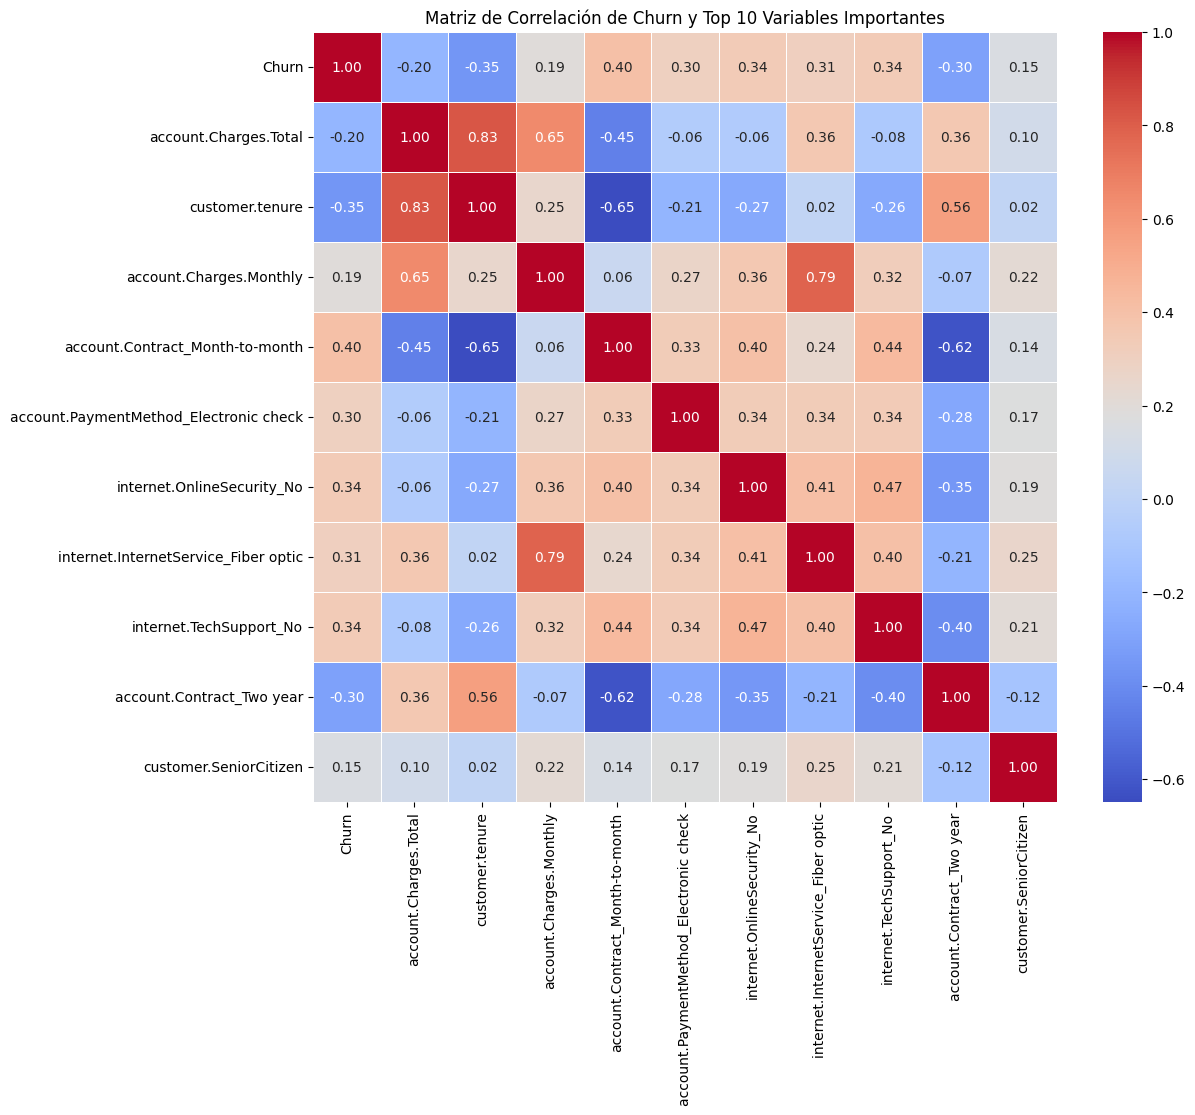


Correlación de las Top 10 Variables con Churn:
account.Charges.Total                    -0.199484
customer.tenure                          -0.354049
account.Charges.Monthly                   0.192858
account.Contract_Month-to-month           0.404565
account.PaymentMethod_Electronic check    0.301455
internet.OnlineSecurity_No                0.342235
internet.InternetService_Fiber optic      0.307463
internet.TechSupport_No                   0.336877
account.Contract_Two year                -0.301552
customer.SeniorCitizen                    0.150541
Name: Churn, dtype: float64


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de correlación
# Incluimos la variable objetivo 'Churn' para ver su correlación con las demás
correlation_matrix = df_final_model.corr()

# Seleccionar las correlaciones con 'Churn' y las 10 más importantes del modelo anterior
# para enfocarnos en las más relevantes
churn_correlations = correlation_matrix['Churn'].sort_values(ascending=False)

# Filtrar las top 10 del modelo y ver sus correlaciones con Churn
top_10_features = importancias.head(10).index.tolist()

# Asegurarnos de que 'Churn' no esté en la lista de características para evitar auto-correlación
if 'Churn' in top_10_features:
    top_10_features.remove('Churn')

# Añadir 'Churn' a las columnas para visualizar
features_for_heatmap = ['Churn'] + top_10_features

# Filtrar la matriz de correlación para estas características
sub_correlation_matrix = correlation_matrix.loc[features_for_heatmap, features_for_heatmap]

plt.figure(figsize=(12, 10))
sns.heatmap(sub_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Churn y Top 10 Variables Importantes')
plt.show()

print("\nCorrelación de las Top 10 Variables con Churn:")
print(churn_correlations[top_10_features])